In [5]:
import pandas as pd
import numpy as py
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
#导入正则表达式模块
import re

In [6]:
data_user=pd.read_csv(r"D:\大学生就业\项目\淘宝用户分析\tianchi_mobile_recommend_train_user.csv")

In [7]:
data_user.isnull().sum()

user_id                0
item_id                0
behavior_type          0
user_geohash     8334824
item_category          0
time                   0
dtype: int64

In [8]:
#数据清洗
data_user['date']=data_user['time'].map(lambda s:s.split(" ")[0])
data_user['hour']=data_user['time'].map(lambda s:s.split(" ")[1])
data_user.head()

,user_id,item_id,behavior_type,user_geohash,item_category,time,date,hour
0,98047837,232431562,1,NaN,4245,2014-12-06 02,2014-12-06,02
1,97726136,383583590,1,NaN,5894,2014-12-09 20,2014-12-09,20
2,98607707,64749712,1,NaN,2883,2014-12-18 11,2014-12-18,11
3,98662432,320593836,1,96nn52n,6562,2014-12-06 10,2014-12-06,10
4,98145908,290208520,1,NaN,13926,2014-12-16 21,2014-12-16,21


In [9]:
data_user.dtypes

user_id           int64
item_id           int64
behavior_type     int64
user_geohash     object
item_category     int64
time             object
date             object
hour             object
dtype: object

In [10]:
data_user['date']=pd.to_datetime(data_user['date'])
data_user['time']=pd.to_datetime(data_user['time'])
data_user['hour']=data_user['hour'].astype('int64')
data_user.dtypes

user_id                   int64
item_id                   int64
behavior_type             int64
user_geohash             object
item_category             int64
time             datetime64[ns]
date             datetime64[ns]
hour                      int64
dtype: object

In [11]:
#异常值处理
data_user=data_user.sort_values(by='time',ascending=True)#排序处理
data_user=data_user.reset_index(drop=True)#建立索引
data_user.describe()

,user_id,item_id,behavior_type,item_category,time,date,hour
count,1.225691e+07,1.225691e+07,1.225691e+07,1.225691e+07,12256906,12256906,1.225691e+07
mean,7.170732e+07,2.023084e+08,1.105271e+00,6.846162e+03,2014-12-04 04:47:28.445702144,2014-12-03 13:58:23.675396352,1.481799e+01
min,4.913000e+03,6.400000e+01,1.000000e+00,2.000000e+00,2014-11-18 00:00:00,2014-11-18 00:00:00,0.000000e+00
25%,3.584965e+07,1.014130e+08,1.000000e+00,3.721000e+03,2014-11-26 15:00:00,2014-11-26 00:00:00,1.000000e+01
50%,7.292804e+07,2.021359e+08,1.000000e+00,6.209000e+03,2014-12-04 14:00:00,2014-12-04 00:00:00,1.600000e+01
75%,1.073774e+08,3.035405e+08,1.000000e+00,1.029000e+04,2014-12-11 23:00:00,2014-12-11 00:00:00,2.000000e+01
max,1.424559e+08,4.045625e+08,4.000000e+00,1.408000e+04,2014-12-18 23:00:00,2014-12-18 00:00:00,2.300000e+01
std,4.122920e+07,1.167397e+08,4.572662e-01,3.809922e+03,NaN,NaN,6.474778e+00


Text(0.5, 1.0, 'uv_daily')

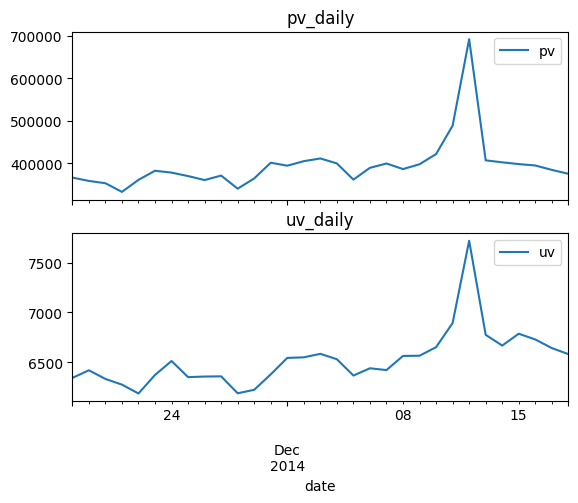

In [12]:
#pv_daily记录每天用户操作次数，uv_daily记录每天不同的上线用户数量
pv_daily=data_user.groupby('date')['user_id'].count().reset_index().rename(columns={'user_id':'pv'})
uv_daily=data_user.groupby('date')['user_id'].apply(lambda x:x.drop_duplicates().count()).reset_index().rename(columns={'user_id':'uv'})
fig,axes=plt.subplots(2,1,sharex=True)
pv_daily.plot(x='date',y='pv',ax=axes[0])
uv_daily.plot(x='date',y='uv',ax=axes[1])
axes[0].set_title('pv_daily')
axes[1].set_title('uv_daily')

Text(0.5, 1.0, 'uv_hour')

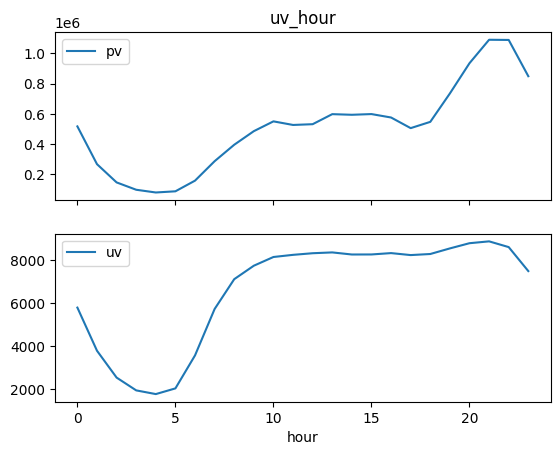

In [13]:
#pv_hour记录每小时用户操作次数，uv_hour记录每小时不同的上线用户数量
pv_hour=data_user.groupby('hour')['user_id'].count().reset_index().rename(columns={'user_id':'pv'})
uv_hour=data_user.groupby('hour')['user_id'].apply(lambda x:x.drop_duplicates().count()).reset_index().rename(columns={'user_id':'uv'})
fig,axes=plt.subplots(2,1,sharex=True)
pv_hour.plot(x='hour',y='pv',ax=axes[0])
uv_hour.plot(x='hour',y='uv',ax=axes[1])
axes[0].set_title('pv_hour')
axes[0].set_title('uv_hour')

Text(0.5, 1.0, 'pv_different_behavior_type_except1')

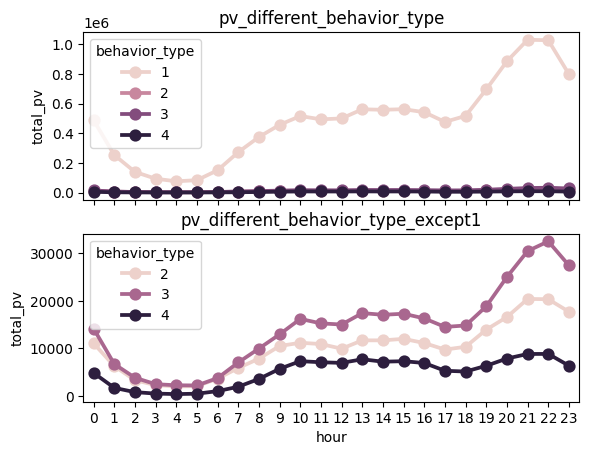

In [14]:
#不同行为类型用户pv分析
pv_detail=data_user.groupby(['behavior_type','hour'])['user_id'].count().reset_index().rename(columns={'user_id':'total_pv'})
fig,axes=plt.subplots(2,1,sharex=True)
sns.pointplot(x='hour',y='total_pv',hue='behavior_type',data=pv_detail,ax=axes[0])
sns.pointplot(x='hour',y='total_pv',hue='behavior_type',data=pv_detail[pv_detail.behavior_type!=1],ax=axes[1])
axes[0].set_title('pv_different_behavior_type')
axes[1].set_title('pv_different_behavior_type_except1')

C:\Users\33951\AppData\Local\Temp\ipykernel_11528\112953547.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_user_buy,kde=False)


Text(0.5, 1.0, 'daily_user_buy')

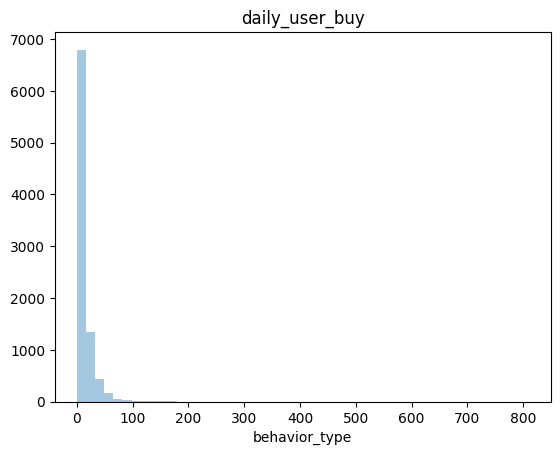

In [15]:
#用户购买次数情况分析
data_user_buy=data_user[data_user.behavior_type==4].groupby('user_id')['behavior_type'].count()
sns.distplot(data_user_buy,kde=False)
plt.title('daily_user_buy')

C:\Users\33951\AppData\Local\Temp\ipykernel_11528\3066758246.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_use_buy1.groupby('date').apply(lambda x:x.total.sum()/x.total.count()).plot()


Text(0.5, 1.0, 'daily_ARPPU')

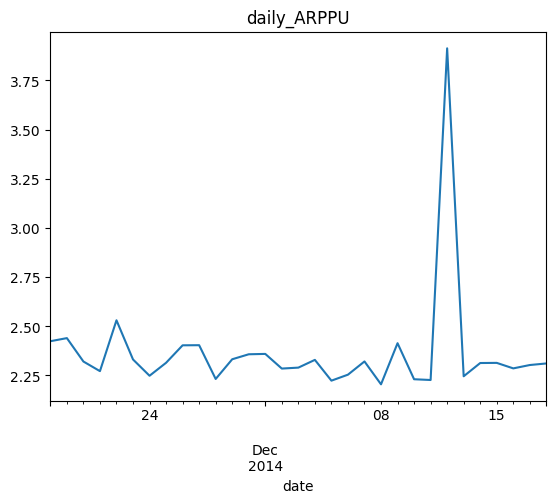

In [16]:
#日ARPPU
#ARPPU（average revenue per paying user）是指从每位付费用户身上获得的收入，它反映的是每个付费用户的平均付费额度。
#ARPPU=总收入/活跃用户付费数量
#因为本数据集中没有消费金额，因此在计算过程中用消费次数代替消费金额
#人均消费次数=消费总次数/消费人数
data_use_buy1=data_user[data_user.behavior_type==4].groupby(['date','user_id'])['behavior_type'].count().reset_index().rename(columns={'behavior_type':'total'})
data_use_buy1.groupby('date').apply(lambda x:x.total.sum()/x.total.count()).plot()
plt.title('daily_ARPPU')

C:\Users\33951\AppData\Local\Temp\ipykernel_11528\3696208979.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_use_buy2.groupby('date').apply(lambda x:x[x.behavior_type==4].total.sum()/len(x.user_id.unique())).plot()


Text(0.5, 1.0, 'daily_ARPU')

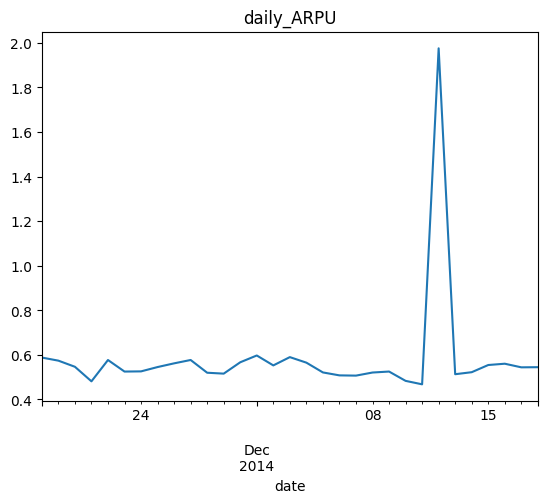

In [17]:
#日ARPU
#ARPU(Average Revenue Per User) ：平均每用户收入，可通过 总收入/AU 计算得出。它可以衡量产品的盈利能力和发展活力。
#活跃用户数平均消费次数=消费总次数/活跃用户人数(每天有操作行为的为活跃)
data_user['operation']=1
data_use_buy2=data_user.groupby(['date','user_id','behavior_type'])['operation'].count().reset_index().rename(columns={'operation':'total'})
data_use_buy2.groupby('date').apply(lambda x:x[x.behavior_type==4].total.sum()/len(x.user_id.unique())).plot()
plt.title('daily_ARPU')

C:\Users\33951\AppData\Local\Temp\ipykernel_11528\3132059078.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_use_buy2.groupby('date').apply(lambda x:x[x.behavior_type==4].total.count()/len(x.user_id.unique())).plot()


Text(0.5, 1.0, 'daily_afford_rate')

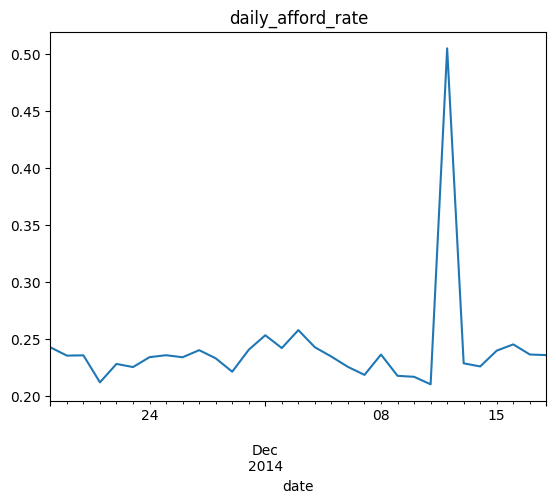

In [18]:
#付费率=消费人数/活跃用户人数
data_use_buy2.groupby('date').apply(lambda x:x[x.behavior_type==4].total.count()/len(x.user_id.unique())).plot()
plt.title('daily_afford_rate')

C:\Users\33951\AppData\Local\Temp\ipykernel_11528\1953842790.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_user_buy3)


大多数用户消费：1次


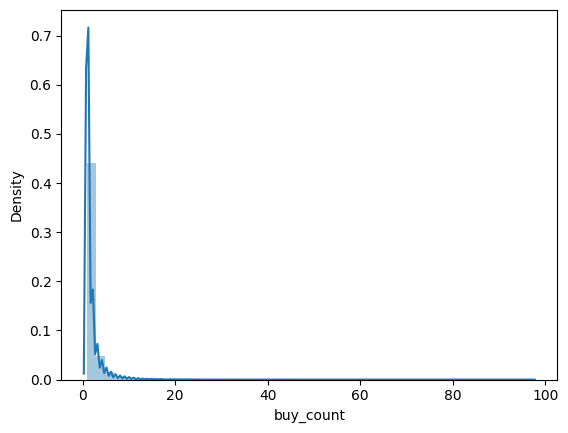

In [19]:
#同一时间段用户消费次数分布
data_user_buy3=data_user[data_user.behavior_type==4].groupby(['user_id','date','hour'])['operation'].sum().rename('buy_count')
data_user_buy3
sns.distplot(data_user_buy3)
print('大多数用户消费：{}次'.format(data_user_buy3.mode()[0]))

In [20]:
#复购率=有复购行为的用户数/有购买行为的用户总数
date_rebuy=data_user[data_user.behavior_type==4].groupby('user_id')['date'].apply(lambda x:len(x.unique())).rename('rebuy_count')
print('复购率:',round(date_rebuy[date_rebuy>=2].count()/date_rebuy.count(),4))

复购率: 0.8717


多数用户复购次数：0次


C:\Users\33951\AppData\Local\Temp\ipykernel_11528\2725719029.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(date_rebuy-1)


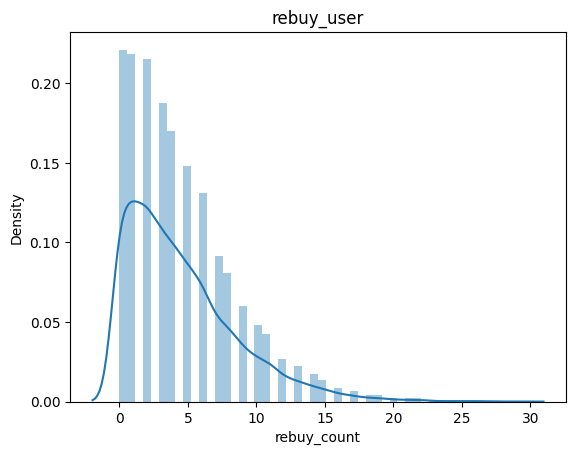

In [21]:
#不同用户平均复购时间分析
sns.distplot(date_rebuy-1)
plt.title('rebuy_user')
print('多数用户复购次数：{}次'.format((date_rebuy-1).mode()[0]))

In [22]:
#漏斗流失分析
data_user_count=data_user.groupby(['behavior_type']).count()
data_user_count.head()

,user_id,item_id,user_geohash,item_category,time,date,hour,operation
behavior_type,,,,,,,,
1,11550581,11550581,3704666,11550581,11550581,11550581,11550581,11550581
2,242556,242556,74365,242556,242556,242556,242556,242556
3,343564,343564,104443,343564,343564,343564,343564,343564
4,120205,120205,38608,120205,120205,120205,120205,120205


In [23]:
pv_all=data_user['user_id'].count()
print(pv_all)

12256906


In [24]:
#不同用户行为类别的转化率
data_category=data_user[data_user.behavior_type!=2].groupby(['item_category','behavior_type']).operation.count().unstack(1).rename(columns={1:'点击量',3:'加入购物车量',4:'购买量'}).fillna(0)
data_category.head()

behavior_type,点击量,加入购物车量,购买量
item_category,,,
2,3.0,0.0,0.0
3,3.0,0.0,0.0
4,1.0,0.0,0.0
6,10.0,0.0,0.0
8,976.0,4.0,4.0


In [25]:
#转化率计算
data_category['转化率']=data_category['购买量']/data_category['点击量']
data_category.head()

behavior_type,点击量,加入购物车量,购买量,转化率
item_category,,,,
2,3.0,0.0,0.0,0.000000
3,3.0,0.0,0.0,0.000000
4,1.0,0.0,0.0,0.000000
6,10.0,0.0,0.0,0.000000
8,976.0,4.0,4.0,0.004098


In [26]:
#异常值处理
data_category=data_category.fillna(0)
data_category=data_category[data_category['转化率']<=1]

C:\Users\33951\AppData\Local\Temp\ipykernel_11528\2720221744.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_category['转化率'])


<Axes: xlabel='转化率', ylabel='Density'>

D:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-8F6C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIE

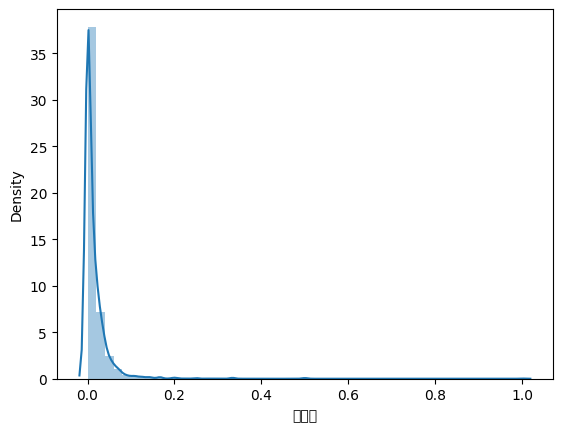

In [27]:
#转化率绘图
sns.distplot(data_category['转化率'])

In [28]:
data_category['感兴趣比率']=data_category['加入购物车量']/data_category['点击量']
data_category.head()

behavior_type,点击量,加入购物车量,购买量,转化率,感兴趣比率
item_category,,,,,
2,3.0,0.0,0.0,0.000000,0.000000
3,3.0,0.0,0.0,0.000000,0.000000
4,1.0,0.0,0.0,0.000000,0.000000
6,10.0,0.0,0.0,0.000000,0.000000
8,976.0,4.0,4.0,0.004098,0.004098


C:\Users\33951\AppData\Local\Temp\ipykernel_11528\1834463284.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_category['感兴趣比率'])


<Axes: xlabel='感兴趣比率', ylabel='Density'>

D:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 24863 (\N{CJK UNIFIED IDEOGRAPH-611F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 20852 (\N{CJK UNIFIED IDEOGRAPH-5174}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 36259 (\N{CJK UNIFIED IDEOGRAPH-8DA3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24863 (\N{CJK UNIFIED IDEOGRAPH-611F}) missing from font(s) DejaVu

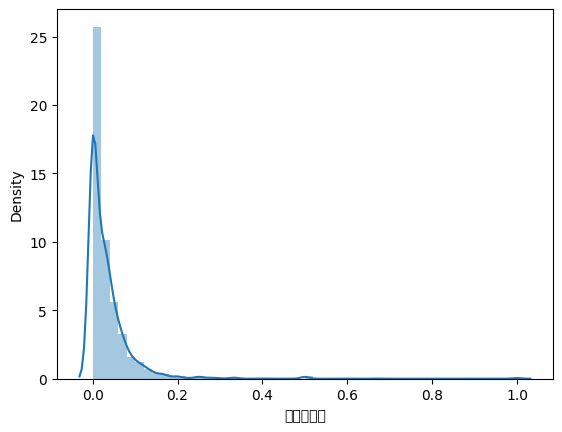

In [29]:
#异常值处理，感兴趣比率绘图
data_category=data_category[data_category['感兴趣比率']<=1]
sns.distplot(data_category['感兴趣比率'])

In [30]:
##将转化率分三类查看各类占比例
data_convert_rate=pd.cut(data_category['转化率'],[-1,0,0.1,1]).value_counts()
data_convert_rate=data_convert_rate/data_convert_rate.sum()
data_convert_rate

转化率
(0.0, 0.1]     0.502693
(-1.0, 0.0]    0.476885
(0.1, 1.0]     0.020422
Name: count, dtype: float64

In [31]:
##将感兴趣比率分三类查看各类占比例
data_interest_rate=pd.cut(data_category['感兴趣比率'],[-1,0,0.1,1]).value_counts()
data_interest_rate=data_interest_rate/data_interest_rate.sum()
data_interest_rate

感兴趣比率
(0.0, 0.1]     0.538487
(-1.0, 0.0]    0.390373
(0.1, 1.0]     0.071140
Name: count, dtype: float64

In [32]:
#二八理论和长尾理论
data_category=data_category[data_category['购买量']>0]
value_8=data_category['购买量'].sum()*0.8
value_10=data_category['购买量'].sum()
data_category=data_category.sort_values(by='购买量',ascending=False)
data_category['累计购买量']=data_category['购买量'].cumsum()
data_category['分类']=data_category['累计购买量'].map(lambda x:'前80%' if x<=value_8 else '后20%')
data_category.head()

behavior_type,点击量,加入购物车量,购买量,转化率,感兴趣比率,累计购买量,分类
item_category,,,,,,,
6344,85369.0,3822.0,2208.0,0.025864,0.044770,2208.0,前80%
1863,371738.0,9309.0,2000.0,0.005380,0.025042,4208.0,前80%
5232,135506.0,4486.0,1611.0,0.011889,0.033106,5819.0,前80%
6977,22806.0,2007.0,1324.0,0.058055,0.088003,7143.0,前80%
8877,63396.0,1974.0,1072.0,0.016910,0.031138,8215.0,前80%


In [33]:
data_category.groupby('分类')['分类'].count()/data_category['分类'].count()

分类
前80%    0.155727
后20%    0.844273
Name: 分类, dtype: float64

In [34]:
from datetime import datetime
datenow=datetime(2014,12,20)

In [35]:
#每位用户最近购买时间
recent_buy_time=data_user[data_user.behavior_type==4].groupby('user_id').date.apply(lambda x:datetime(2014,12,20)-x.sort_values().iloc[-1]).reset_index().rename(columns={'date':'recent'})
recent_buy_time.recent=recent_buy_time.recent.map(lambda x:x.days)
recent_buy_time

,user_id,recent
0,4913,4
1,6118,3
2,7528,7
3,7591,7
4,12645,6
...,...,...
8881,142376113,12
8882,142412247,5
8883,142430177,2
8884,142450275,7


In [36]:
#每个用户消费频率
buy_freq=data_user[data_user.behavior_type==4].groupby('user_id').date.count().reset_index().rename(columns={'date':'freq'})
rfm=pd.merge(recent_buy_time,buy_freq,left_on='user_id',right_on='user_id',how='outer')
rfm

,user_id,recent,freq
0,4913,4,6
1,6118,3,1
2,7528,7,6
3,7591,7,21
4,12645,6,8
...,...,...,...
8881,142376113,12,1
8882,142412247,5,12
8883,142430177,2,5
8884,142450275,7,40


In [37]:
#将各维度分成两个程度,分数越高越好
rfm['recent_value']=pd.qcut(rfm.recent,2,labels=['2','1'])
rfm['freq_value']=pd.qcut(rfm.freq,2,labels=['1','2'])
rfm['rfm']=rfm['recent_value'].str.cat(rfm['freq_value'])
rfm.head()

,user_id,recent,freq,recent_value,freq_value,rfm
0,4913,4,6,2,1,21
1,6118,3,1,2,1,21
2,7528,7,6,1,1,11
3,7591,7,21,1,2,12
4,12645,6,8,2,1,21
